<a href="https://colab.research.google.com/github/chuy-zip/PROYECTO2_DS/blob/main/PROY2_DS_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
!git clone https://github.com/chuy-zip/PROYECTO2_DS.git

fatal: destination path 'PROYECTO2_DS' already exists and is not an empty directory.


In [35]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split, WeightedRandomSampler
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import pandas as pd
import numpy as np
import torch.optim as optim
import time
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [36]:
torch.manual_seed(42)
np.random.seed(42)

df = pd.read_csv("PROYECTO2_DS/data/train_clean.csv")
print(df.head())

print("\n CARGADO DE DATOS ")
df = pd.read_csv("PROYECTO2_DS/data/train_clean.csv")
print(f"Dimensiones del dataset: {df.shape}")

# Ver distribución de clases
print("\n Distribución de clases:")
print(df["discourse_effectiveness"].value_counts())

   Unnamed: 0  discourse_id      essay_id discourse_type  \
0           0  0013cc385424  007ACE74B050           Lead   
1           1  9704a709b505  007ACE74B050       Position   
2           2  c22adee811b6  007ACE74B050          Claim   
3           3  a10d361e54e4  007ACE74B050       Evidence   
4           4  db3e453ec4e2  007ACE74B050   Counterclaim   

  discourse_effectiveness                                         text_clean  
0                Adequate  hi isaac going writing face mar natural landfo...  
1                Adequate  perspective think face natural landform dont t...  
2                Adequate  think face natural landform no life mar descov...  
3                Adequate  life mar would know reason think natural landf...  
4                Adequate  people thought face formed alieans thought lif...  

 CARGADO DE DATOS 
Dimensiones del dataset: (36765, 6)

 Distribución de clases:
discourse_effectiveness
Adequate       20977
Effective       9326
Ineffective     6

In [37]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['discourse_effectiveness'])
print(f"\nMapping de clases: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")


Mapping de clases: {'Adequate': np.int64(0), 'Effective': np.int64(1), 'Ineffective': np.int64(2)}


In [38]:
print("\n PREPROCESAMIENTO ")

# Tokenizador
def tokenizer(text):
    text = str(text).lower()

    text = text.replace('<br />', ' ').replace('\n', ' ').replace('\t', ' ')

    tokens = text.split()
    return tokens

# Aplicar tokenización
df['tokens'] = df['text_clean'].apply(tokenizer)

# Construir vocabulario
def build_vocab(token_lists, min_freq=2, max_vocab_size=35000):
    counter = Counter()
    for tokens in token_lists:
        counter.update(tokens)

    # Ordenar por frecuencia y limitar tamaño
    most_common = counter.most_common(max_vocab_size-2)

    vocab = {'<pad>': 0, '<unk>': 1}
    for idx, (word, count) in enumerate(most_common):
        if count >= min_freq:
            vocab[word] = idx + 2

    print(f"Tamaño del vocabulario: {len(vocab)}")
    print(f"Palabras más comunes: {list(vocab.keys())[:10]}")
    return vocab

vocab = build_vocab(df['tokens'])
vocab_size = len(vocab)

# Convertir a índices y aplicar padding con longitud dinámica
def tokens_to_indices(tokens_list, vocab, max_length=200):
    sequences = []
    for tokens in tokens_list:
        indices = [vocab.get(token, vocab['<unk>']) for token in tokens]
        # No truncar demasiado agresivamente
        indices = indices[:max_length]
        sequences.append(torch.tensor(indices, dtype=torch.long))

    padded_sequences = pad_sequence(sequences, batch_first=True, padding_value=vocab['<pad>'])
    return padded_sequences

# Convertir textos a tensores con longitud más generosa
X = tokens_to_indices(df['tokens'], vocab, max_length=200)
y = torch.tensor(df['label'].values, dtype=torch.long)

print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")


 PREPROCESAMIENTO 
Tamaño del vocabulario: 11495
Palabras más comunes: ['<pad>', '<unk>', 'student', 'not', 'would', 'people', 'vote', 'school', 'electoral', 'college']
Forma de X: torch.Size([36765, 200])
Forma de y: torch.Size([36765])


In [39]:
print("\n DIVISIÓN DE DATOS CON BALANCEO ")

# División estratificada
train_idx, temp_idx = train_test_split(
    range(len(X)),
    test_size=0.3,
    stratify=y.numpy(),  # Convertir a numpy para stratify
    random_state=42
)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=y.numpy()[temp_idx],  # Convertir a numpy para stratify
    random_state=42
)

# Crear datasets
train_dataset = TensorDataset(X[train_idx], y[train_idx])
val_dataset = TensorDataset(X[val_idx], y[val_idx])
test_dataset = TensorDataset(X[test_idx], y[test_idx])

print(f"Entrenamiento: {len(train_dataset)} ejemplos")
print(f"Validación: {len(val_dataset)} ejemplos")
print(f"Prueba: {len(test_dataset)} ejemplos")

# Calcular pesos para balancear clases
class_counts = df['discourse_effectiveness'].value_counts().sort_index()
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)

print(f"\nPesos de clases para balanceo: {class_weights.to_dict()}")

# Weighted Random Sampler para entrenamiento - CORREGIDO
train_labels = y[train_idx].numpy()  # Convertir a numpy array

# Crear un mapeo de índices numéricos a pesos
class_weights_dict = {
    0: class_weights['Adequate'],    # Adequate -> 0
    1: class_weights['Effective'],   # Effective -> 1
    2: class_weights['Ineffective']  # Ineffective -> 2
}

# Asignar pesos usando el mapeo
sample_weights = [class_weights_dict[label] for label in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)



 DIVISIÓN DE DATOS CON BALANCEO 
Entrenamiento: 25735 ejemplos
Validación: 5515 ejemplos
Prueba: 5515 ejemplos

Pesos de clases para balanceo: {'Adequate': 0.46185738273337573, 'Effective': 1.0388572075485765, 'Ineffective': 1.4992854097180477}


In [40]:
print("\n=== CONSTRUYENDO MODELO LSTM AVANZADO ===")

class AdvancedLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, num_classes, dropout=0.5):
        super(AdvancedLSTMClassifier, self).__init__()

        # Embedding layer con más dimensiones
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # LSTM bidireccional con más capacidad
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers,
                           batch_first=True, dropout=dropout, bidirectional=True)

        # Mecanismo de atención mejorado
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

        # Capa de contexto adicional desde estados ocultos LSTM
        self.hidden_transform = nn.Linear(hidden_dim * 2 * num_layers, hidden_dim * 2)

        # Clasificador más profundo y robusto
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim * 2),  # Concatenamos atención + hidden states
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        # Embedding
        embedded = self.embedding(x)

        # LSTM
        lstm_out, (hidden, cell) = self.lstm(embedded)

        # Mecanismo de atención
        attention_weights = torch.softmax(self.attention(lstm_out).squeeze(-1), dim=1)
        context_vector = torch.sum(attention_weights.unsqueeze(-1) * lstm_out, dim=1)

        # Información de los estados ocultos
        hidden_combined = hidden.permute(1, 0, 2).contiguous().view(hidden.size(1), -1)
        hidden_features = self.hidden_transform(hidden_combined)

        # Combinar características de atención y estados ocultos
        combined_features = torch.cat([context_vector, hidden_features], dim=1)

        # Clasificación final
        output = self.classifier(combined_features)
        return output

# Hiperparámetros optimizados
EMBEDDING_DIM = 300
HIDDEN_DIM = 256
NUM_LAYERS = 3
NUM_EPOCHS = 25
LEARNING_RATE = 0.001
BATCH_SIZE = 64
DROPOUT = 0.5
NUM_CLASSES = 3

# Instanciar modelo avanzado
advanced_model = AdvancedLSTMClassifier(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
)

# Contar parámetros
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Parámetros del modelo avanzado: {count_parameters(advanced_model):,}")
#print(f"Arquitectura del modelo:\n{advanced_model}")


=== CONSTRUYENDO MODELO LSTM AVANZADO ===
Parámetros del modelo avanzado: 9,322,168


In [41]:
print("\nCONFIGURACIÓN DE ENTRENAMIENTO AVANZADO ")

# DataLoaders con balanceo
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Mover a GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
advanced_model = advanced_model.to(device)
print(f"Modelo movido a: {device}")

# Preparar pesos para pérdida balanceada
class_weights_tensor = torch.tensor([class_weights[0], class_weights[1], class_weights[2]],
                                   dtype=torch.float).to(device)

print(f"Pesos para pérdida: {class_weights_tensor.cpu().numpy()}")


CONFIGURACIÓN DE ENTRENAMIENTO AVANZADO 
Modelo movido a: cuda
Pesos para pérdida: [0.46185738 1.0388572  1.4992855 ]


/tmp/ipython-input-686989671.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  class_weights_tensor = torch.tensor([class_weights[0], class_weights[1], class_weights[2]],


In [42]:
print("\n ENTRENAMIENTO AVANZADO ")

def train_advanced_model(model, train_loader, val_loader, num_epochs, learning_rate, num_classes, model_name="LSTM Avanzado"):
    # Optimizador con weight decay
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)

    # Loss function con pesos balanceados
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    # Scheduler sin el parámetro verbose (causa el error)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=2, factor=0.5
        # Removido: verbose=True
    )

    train_losses = []
    val_accuracies = []
    val_f1_scores = []
    best_accuracy = 0
    patience = 6
    patience_counter = 0
    current_lr = learning_rate  # Track manual del learning rate

    print(f"Iniciando entrenamiento de {model_name}...")

    for epoch in range(num_epochs):
        start_time = time.time()

        # ===== FASE DE ENTRENAMIENTO =====
        model.train()
        total_loss = 0
        batch_count = 0

        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs, labels)
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            batch_count += 1

        # ===== FASE DE VALIDACIÓN =====
        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for texts, labels in val_loader:
                texts, labels = texts.to(device), labels.to(device)
                outputs = model(texts)
                _, predicted = torch.max(outputs, 1)

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        # ===== CÁLCULO DE MÉTRICAS =====
        avg_loss = total_loss / batch_count
        accuracy = accuracy_score(all_labels, all_preds)

        # Reporte de clasificación para F1-score
        report = classification_report(all_labels, all_preds,
                                    target_names=label_encoder.classes_, output_dict=True)
        f1_macro = report['macro avg']['f1-score']

        epoch_time = time.time() - start_time

        # ===== LEARNING RATE SCHEDULING =====
        old_lr = current_lr
        scheduler.step(accuracy)
        current_lr = optimizer.param_groups[0]['lr']

        # Verificar si el LR cambió
        lr_changed = (old_lr != current_lr)

        # ===== EARLY STOPPING =====
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            patience_counter = 0
            torch.save(model.state_dict(), 'best_advanced_lstm_model.pth')
            print(f" Nuevo mejor modelo guardado (Accuracy: {accuracy:.4f})")
        else:
            patience_counter += 1

        train_losses.append(avg_loss)
        val_accuracies.append(accuracy)
        val_f1_scores.append(f1_macro)

        # ===== LOGGING DETALLADO =====
        print(f'\nEpoch {epoch+1}/{num_epochs}:')
        print(f'  Loss: {avg_loss:.4f} | Val Accuracy: {accuracy:.4f} | F1-Macro: {f1_macro:.4f}')
        print(f'  Time: {epoch_time:.2f}s | LR: {current_lr:.6f}' + (' 📉' if lr_changed else ''))
        print(f'  Early stopping: {patience_counter}/{patience}')

        # Reporte completo cada 4 épocas
        if (epoch + 1) % 4 == 0 or epoch == 0:
            print(f'\n  Classification Report (Epoch {epoch+1}):')
            print(classification_report(all_labels, all_preds,
                                      target_names=label_encoder.classes_))

        # Early stopping
        if patience_counter >= patience:
            print(f"\n Early stopping activado en epoch {epoch+1}")
            break

    return {
        'train_losses': train_losses,
        'val_accuracies': val_accuracies,
        'val_f1_scores': val_f1_scores,
        'best_accuracy': best_accuracy,
        'final_epoch': epoch + 1
    }

# Entrenar el modelo avanzado
advanced_results = train_advanced_model(
    model=advanced_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    num_classes=NUM_CLASSES,
    model_name="LSTM Avanzado"
)


 ENTRENAMIENTO AVANZADO 
Iniciando entrenamiento de LSTM Avanzado...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

 Nuevo mejor modelo guardado (Accuracy: 0.3014)

Epoch 1/25:
  Loss: 0.8728 | Val Accuracy: 0.3014 | F1-Macro: 0.3018
  Time: 64.97s | LR: 0.001000
  Early stopping: 0/6

  Classification Report (Epoch 1):
              precision    recall  f1-score   support

    Adequate       0.00      0.00      0.00      3146
   Effective       0.57      0.54      0.55      1399
 Ineffective       0.22      0.94      0.35       970

    accuracy                           0.30      5515
   macro avg       0.26      0.49      0.30      5515
weighted avg       0.18      0.30      0.20      5515



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


 Nuevo mejor modelo guardado (Accuracy: 0.3394)

Epoch 2/25:
  Loss: 0.7101 | Val Accuracy: 0.3394 | F1-Macro: 0.3169
  Time: 64.10s | LR: 0.001000
  Early stopping: 0/6
 Nuevo mejor modelo guardado (Accuracy: 0.3958)

Epoch 3/25:
  Loss: 0.6160 | Val Accuracy: 0.3958 | F1-Macro: 0.4037
  Time: 63.97s | LR: 0.001000
  Early stopping: 0/6

Epoch 4/25:
  Loss: 0.4777 | Val Accuracy: 0.3882 | F1-Macro: 0.3804
  Time: 64.06s | LR: 0.001000
  Early stopping: 1/6

  Classification Report (Epoch 4):
              precision    recall  f1-score   support

    Adequate       0.65      0.11      0.20      3146
   Effective       0.40      0.84      0.54      1399
 Ineffective       0.30      0.62      0.41       970

    accuracy                           0.39      5515
   macro avg       0.45      0.53      0.38      5515
weighted avg       0.53      0.39      0.32      5515

 Nuevo mejor modelo guardado (Accuracy: 0.5053)

Epoch 5/25:
  Loss: 0.4042 | Val Accuracy: 0.5053 | F1-Macro: 0.4938
  T


 EVALUACIÓN FINAL
 RESULTADOS FINALES - TEST SET
Accuracy: 0.6044
F1-Score Macro: 0.5154
F1-Score Weighted: 0.5885

 REPORTE DE CLASIFICACIÓN DETALLADO:
              precision    recall  f1-score   support

    Adequate       0.64      0.76      0.69      3147
   Effective       0.60      0.50      0.55      1399
 Ineffective       0.40      0.25      0.31       969

    accuracy                           0.60      5515
   macro avg       0.55      0.50      0.52      5515
weighted avg       0.59      0.60      0.59      5515


 ANÁLISIS POR CLASE:
  Adequate:
    Precision: 0.6394
    Recall:    0.7595
    F1-Score:  0.6943
    Support:   3147.0
  Effective:
    Precision: 0.5993
    Recall:    0.5025
    F1-Score:  0.5467
    Support:   1399.0
  Ineffective:
    Precision: 0.3974
    Recall:    0.2477
    F1-Score:  0.3051
    Support:   969.0


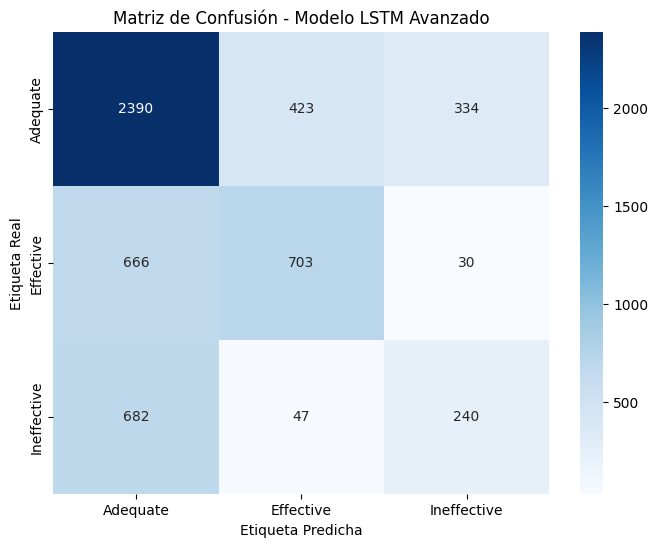

In [43]:
print("\n EVALUACIÓN FINAL")

# Cargar mejor modelo
advanced_model.load_state_dict(torch.load('best_advanced_lstm_model.pth'))

# Evaluar en test
advanced_model.eval()
test_preds = []
test_labels = []
test_probabilities = []

with torch.no_grad():
    for texts, labels in test_loader:
        texts, labels = texts.to(device), labels.to(device)
        outputs = advanced_model(texts)
        probabilities = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
        test_probabilities.extend(probabilities.cpu().numpy())

# Métricas finales
test_accuracy = accuracy_score(test_labels, test_preds)
report = classification_report(test_labels, test_preds,
                              target_names=label_encoder.classes_, output_dict=True)

print(f" RESULTADOS FINALES - TEST SET")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"F1-Score Macro: {report['macro avg']['f1-score']:.4f}")
print(f"F1-Score Weighted: {report['weighted avg']['f1-score']:.4f}")

print("\n REPORTE DE CLASIFICACIÓN DETALLADO:")
print(classification_report(test_labels, test_preds,
                          target_names=label_encoder.classes_))

# Análisis por clase
print("\n ANÁLISIS POR CLASE:")
for i, class_name in enumerate(label_encoder.classes_):
    class_report = report[class_name]
    print(f"  {class_name}:")
    print(f"    Precision: {class_report['precision']:.4f}")
    print(f"    Recall:    {class_report['recall']:.4f}")
    print(f"    F1-Score:  {class_report['f1-score']:.4f}")
    print(f"    Support:   {class_report['support']}")

# Matriz de confusión
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Matriz de Confusión - Modelo LSTM Avanzado')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()